In [1]:
import pandas as pd

df = pd.read_csv('Customer Purchasing Behaviors.csv')
print(df.head())

   user_id  age  annual_income  purchase_amount  loyalty_score region  \
0        1   25          45000              200            4.5  North   
1        2   34          55000              350            7.0  South   
2        3   45          65000              500            8.0   West   
3        4   22          30000              150            3.0   East   
4        5   29          47000              220            4.8  North   

   purchase_frequency  
0                  12  
1                  18  
2                  22  
3                  10  
4                  13  


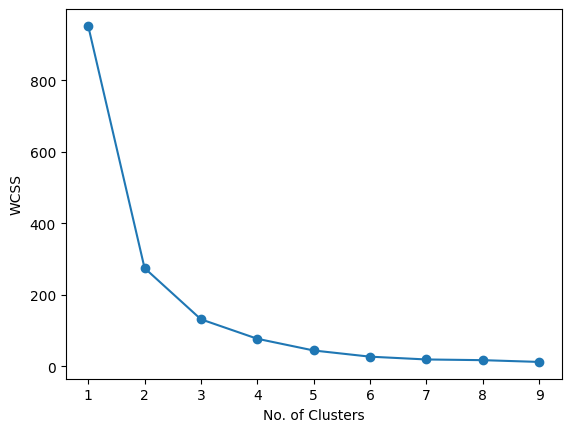

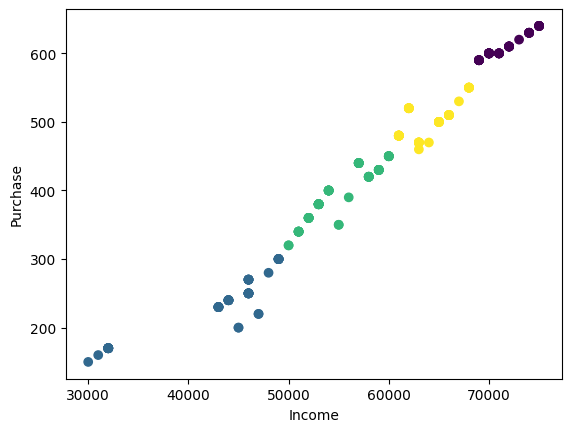

   user_id  age  annual_income  purchase_amount  loyalty_score region  \
0        1   25          45000              200            4.5  North   
1        2   34          55000              350            7.0  South   
2        3   45          65000              500            8.0   West   
3        4   22          30000              150            3.0   East   
4        5   29          47000              220            4.8  North   

   purchase_frequency  Cluster  
0                  12        1  
1                  18        2  
2                  22        3  
3                  10        1  
4                  13        1  


In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv('Customer Purchasing Behaviors.csv')

# Remove duplicates
df.drop_duplicates(inplace=True)

# Select features
X = df[['annual_income', 'purchase_amount', 'purchase_frequency', 'loyalty_score']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss, marker='o')
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.show()

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualization
plt.scatter(df['annual_income'], df['purchase_amount'], c=df['Cluster'])
plt.xlabel("Income")
plt.ylabel("Purchase")
plt.show()

print(df.head())